<a href="https://colab.research.google.com/github/soniaibounouportfolio/soniaibounou/blob/main/Matrice_et_r%C3%A9gressions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
dataframe = pd.read_excel('/content/STATS-DATA-MKT_PC Pairagogie_Données.xlsx')


In [ ]:
dataframe.head()

,customer_id,csat_1_5,loyalty_index_1_5,nps_1_9,tenure_months,recency_days,purchase_frequency_90d,monetary_90d,clv_estimate,ces_1_7,complaint_last_6m,churn_90d
0,1,2,2,5,1.000000,218,2.625258,47.95,205.55,5,1,1
1,2,3,3,6,9.504288,203,5.099389,44.67,208.31,4,0,0
2,3,2,2,2,1.000000,261,3.174638,35.27,162.24,4,0,0
3,4,1,2,4,4.199160,264,4.366653,52.05,228.56,6,0,0
4,5,3,3,4,7.367086,208,4.580429,59.48,287.01,4,0,0


In [ ]:
dataframe.corr()

,customer_id,csat_1_5,loyalty_index_1_5,nps_1_9,tenure_months,recency_days,purchase_frequency_90d,monetary_90d,clv_estimate,ces_1_7,complaint_last_6m,churn_90d
customer_id,1.000000,0.017508,0.028963,0.005632,0.020542,-0.024896,0.015754,0.027941,0.030616,-0.028338,-0.001262,-0.001694
csat_1_5,0.017508,1.000000,0.866160,0.822999,0.823585,-0.872341,0.653444,0.650127,0.706259,-0.873807,-0.105378,-0.530268
loyalty_index_1_5,0.028963,0.866160,1.000000,0.820939,0.814401,-0.869656,0.749189,0.748558,0.814386,-0.867120,-0.098767,-0.528677
nps_1_9,0.005632,0.822999,0.820939,1.000000,0.773196,-0.828718,0.615395,0.620352,0.676190,-0.762415,-0.075186,-0.476300
tenure_months,0.020542,0.823585,0.814401,0.773196,1.000000,-0.818178,0.617465,0.615282,0.677944,-0.761240,-0.083963,-0.444530
recency_days,-0.024896,-0.872341,-0.869656,-0.828718,-0.818178,1.000000,-0.652316,-0.649719,-0.706934,0.814292,0.085269,0.501504
purchase_frequency_90d,0.015754,0.653444,0.749189,0.615395,0.617465,-0.652316,1.000000,0.563684,0.614696,-0.643996,-0.053918,-0.373422
monetary_90d,0.027941,0.650127,0.748558,0.620352,0.615282,-0.649719,0.563684,1.000000,0.984652,-0.654314,-0.074560,-0.359529
clv_estimate,0.030616,0.706259,0.814386,0.676190,0.677944,-0.706934,0.614696,0.984652,1.000000,-0.711227,-0.081550,-0.379544
ces_1_7,-0.028338,-0.873807,-0.867120,-0.762415,-0.761240,0.814292,-0.643996,-0.654314,-0.711227,1.000000,0.100572,0.498659


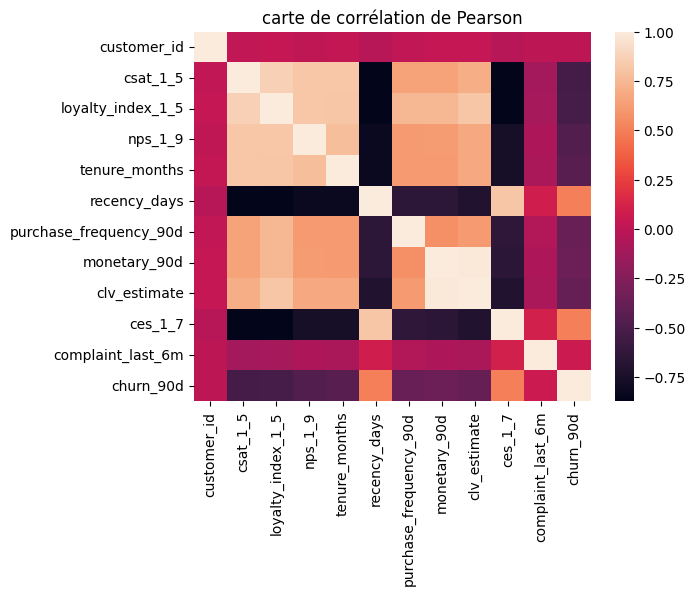

In [ ]:
sns.heatmap(dataframe.corr()).set_title('carte de corrélation de Pearson');

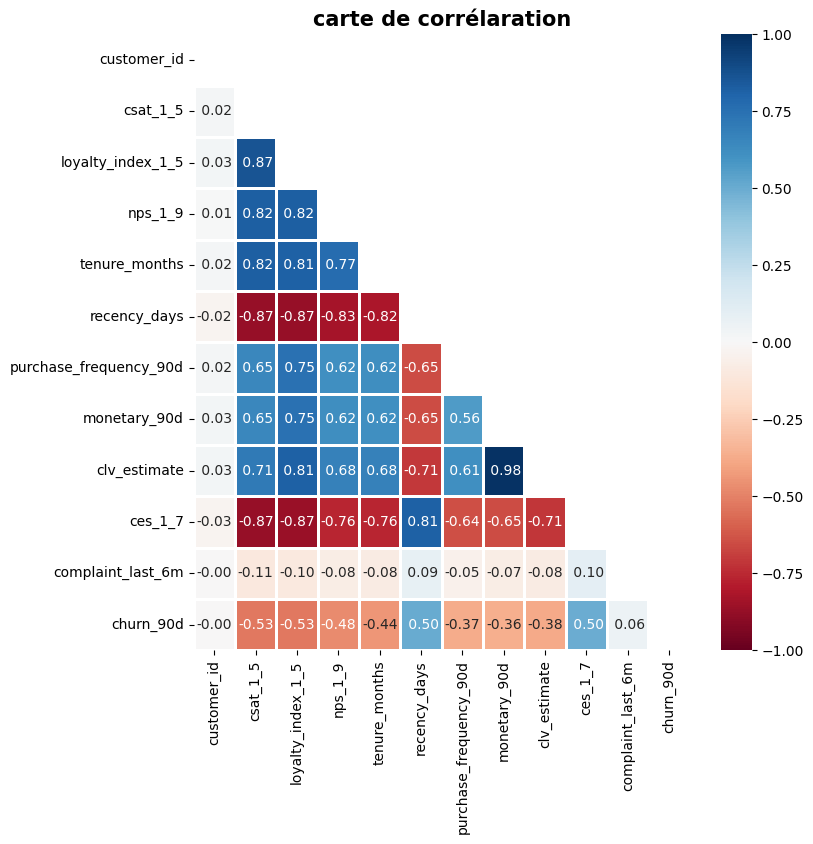

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
mask = np.triu(np.ones_like(dataframe.corr(),dtype=bool))
sns.heatmap(dataframe.corr(),mask=mask, center =0, cmap = 'RdBu', linewidths=1,annot=True, fmt=" .2f", vmin=-1, vmax=1)
plt.title('carte de corrélaration', fontsize=15,fontweight='bold')
plt.show()

In [ ]:
def correlation_matrix(df):
  mask = np.triu(np.ones_like(df.corr(),dtype=bool))
  sns.heatmap(df.corr(),mask=mask, center =0, cmap = 'RdBu', linewidths=1,annot=True, fmt=" .2f", vmin=-1, vmax=1)
  plt.title('carte de corrélaration', fontsize=15,fontweight='bold')
  plt.show()

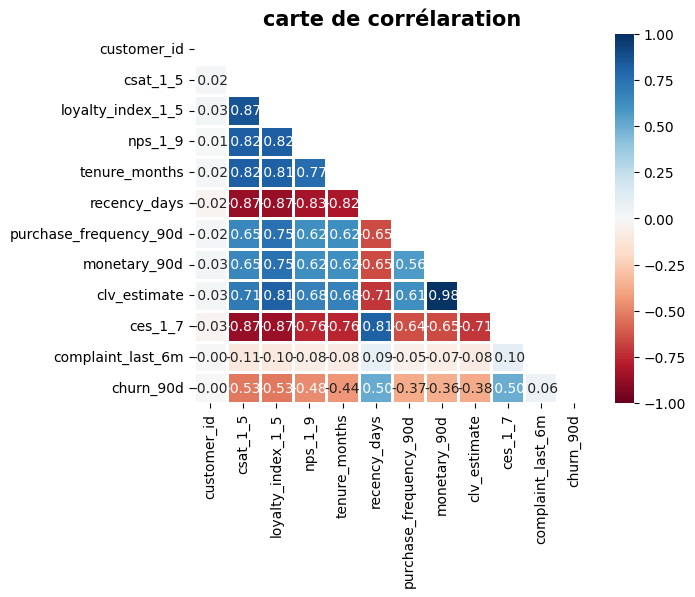

In [ ]:
correlation_matrix(dataframe)

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
file_path = "/content/STATS-DATA-MKT_PC Pairagogie_Données.xlsx"
df = pd.read_excel(file_path)

In [ ]:
# Variables indépendantes (X) et dépendante (Y)
X = df[["csat_1_5", "recency_days", "tenure_months","complaint_last_6m"]]  # Variables indépendantes
Y = df["loyalty_index_1_5"]


Résumé du modèle :

                            OLS Regression Results                            
Dep. Variable:      loyalty_index_1_5   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     3298.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:00:05   Log-Likelihood:                -1542.0
No. Observations:                3000   AIC:                             3094.
Df Residuals:                    2995   BIC:                             3124.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             

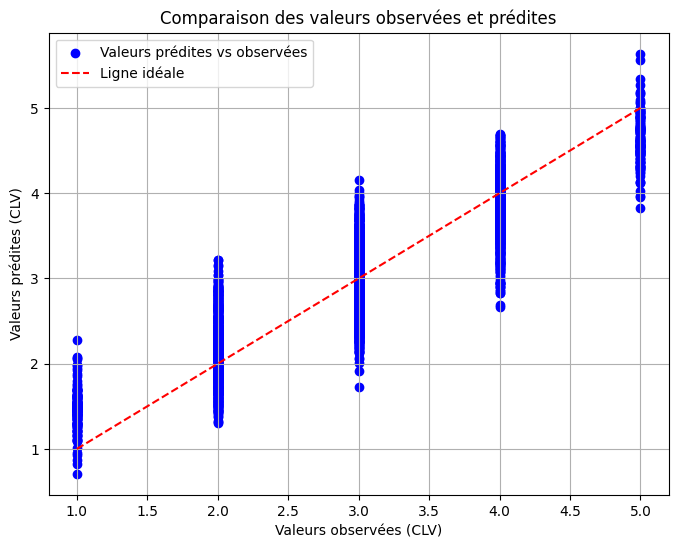

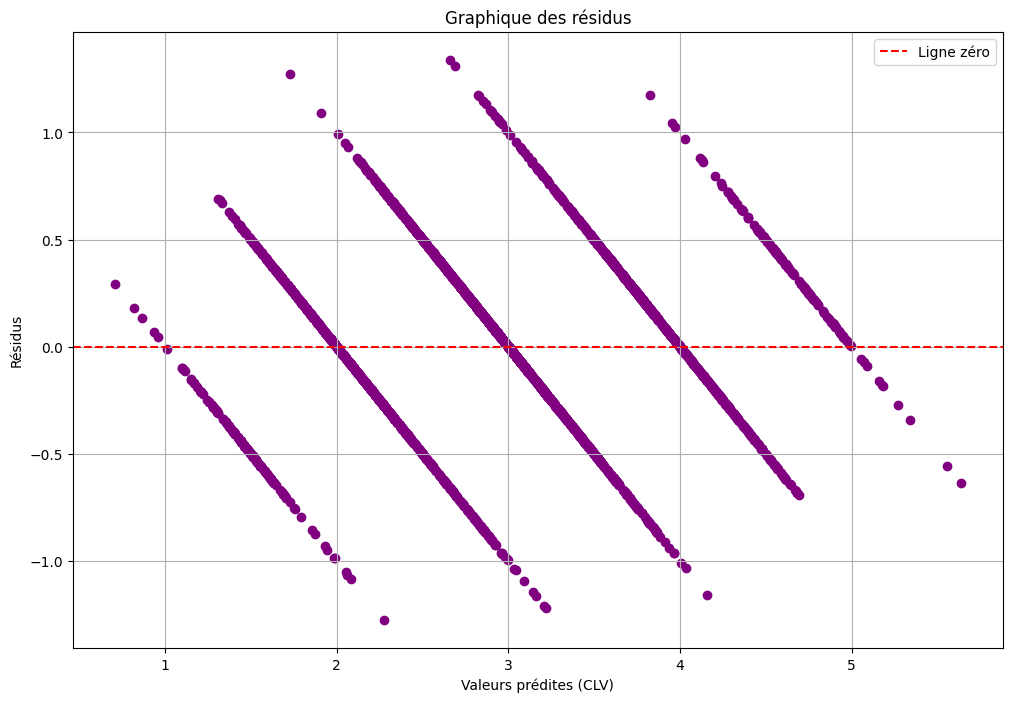

In [ ]:
# Ajout d'une constante pour l'ordonnée à l'origine
X = sm.add_constant(X)

# Création du modèle de régression multiple avec statsmodels - Ordinary Least Square | MCO
model = sm.OLS(Y, X).fit()

# Résultats principaux
print("Résumé du modèle :\n")
print(model.summary())

# Récupération des coefficients, p-values et statistiques F
coefficients = model.params
p_values = model.pvalues
f_stat = model.fvalue
f_pvalue = model.f_pvalue
r2 = model.rsquared

# Interprétation des résultats
print("\nInterprétation :")
print(f"- Les coefficients estimés :\n{coefficients}")
print(f"- Les p-values associées :\n{p_values}")
print(f"- Statistique de Fischer (F-statistic) : {f_stat:.2f}")
print(f"- p-value de la statistique de Fischer : {f_pvalue:.4f}")
print(f"- Coefficient de détermination R² : {r2:.2f}")

# Visualisation des résultats
# 1. Comparaison des valeurs observées et prédites
Y_pred = model.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(Y, Y_pred, color='blue', label='Valeurs prédites vs observées')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], color='red', linestyle='--', label='Ligne idéale')
plt.title('Comparaison des valeurs observées et prédites')
plt.xlabel('Valeurs observées (CLV)')
plt.ylabel('Valeurs prédites (CLV)')
plt.legend()
plt.grid()
plt.show()

# 2. Résidus du modèle
residuals = Y - Y_pred

plt.figure(figsize=(12, 8))
plt.scatter(Y_pred, residuals, color='purple')
plt.axhline(0, color='red', linestyle='--', label='Ligne zéro')
plt.title('Graphique des résidus')
plt.xlabel('Valeurs prédites (CLV)')
plt.ylabel('Résidus')
plt.legend()
plt.grid()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

In [ ]:
file_path = "/content/STATS-DATA-MKT_PC Pairagogie_Données.xlsx"
df = pd.read_excel(file_path)

# Variables indépendantes (X) et dépendante (Y)
X = df[["csat_1_5", "nps_1_9", "ces_1_7", "loyalty_index_1_5", "purchase_frequency_90d", "monetary_90d", "recency_days", "tenure_months","complaint_last_6m"]]  # Variables indépendantes
Y = df["churn_90d"]

In [ ]:
df

,customer_id,csat_1_5,loyalty_index_1_5,nps_1_9,tenure_months,recency_days,purchase_frequency_90d,monetary_90d,clv_estimate,ces_1_7,complaint_last_6m,churn_90d
0,1,2,2,5,1.000000,218,2.625258,47.95,205.55,5,1,1
1,2,3,3,6,9.504288,203,5.099389,44.67,208.31,4,0,0
2,3,2,2,2,1.000000,261,3.174638,35.27,162.24,4,0,0
3,4,1,2,4,4.199160,264,4.366653,52.05,228.56,6,0,0
4,5,3,3,4,7.367086,208,4.580429,59.48,287.01,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,2,3,5,1.723868,223,4.954723,56.60,302.90,5,0,0
2996,2997,2,2,3,6.607348,246,2.320520,51.38,220.59,4,0,1
2997,2998,4,4,7,11.250329,178,4.323019,111.75,669.24,2,0,0
2998,2999,4,4,6,10.817907,154,5.932975,98.60,582.26,3,0,0


Optimization terminated successfully.
         Current function value: 0.332242
         Iterations 7
Résumé du modèle :

                           Logit Regression Results                           
Dep. Variable:              churn_90d   No. Observations:                 2100
Model:                          Logit   Df Residuals:                     2090
Method:                           MLE   Df Model:                            9
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                  0.3528
Time:                        23:06:35   Log-Likelihood:                -697.71
converged:                       True   LL-Null:                       -1078.0
Covariance Type:            nonrobust   LLR p-value:                6.576e-158
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      1.3758      1.602      0.859      0.3

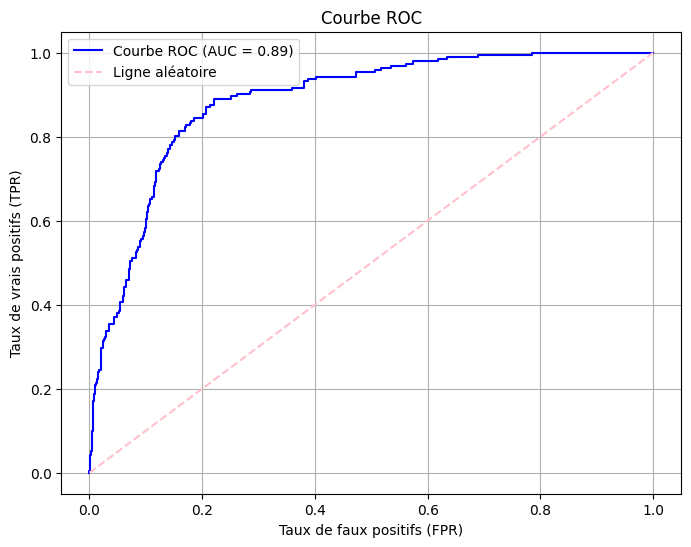

In [ ]:
# Ajout d'une constante pour l'ordonnée à l'origine
X = sm.add_constant(X)

# Division des données en ensembles d'entraînement et de test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Création du modèle de régression logistique
model = sm.Logit(Y_train, X_train).fit()

# Résumé du modèle
print("Résumé du modèle :\n")
print(model.summary())

# Prédictions
Y_pred_prob = model.predict(X_test)
Y_pred = (Y_pred_prob >= 0.5).astype(int)  # Seuil de 0.5 pour classifier

# Évaluation du modèle
print("\nÉvaluation du modèle :")
print(classification_report(Y_test, Y_pred))

# Matrice de confusion
cm = confusion_matrix(Y_test, Y_pred)
print("\nMatrice de confusion :\n", cm)

# Calcul de l'AUC (Area Under Curve)
roc_auc = roc_auc_score(Y_test, Y_pred_prob)
print(f"\nAUC (Area Under Curve) : {roc_auc:.2f}")

# Tracé de la courbe ROC
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Courbe ROC (AUC = {roc_auc:.2f})", color='blue')
plt.plot([0, 1], [0, 1], color='pink', linestyle='--', label="Ligne aléatoire")
plt.title("Courbe ROC")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.legend()
plt.grid()
plt.show()


In [ ]:
Y_pred_prob

,0
1801,0.094253
1190,0.042514
1817,0.709069
251,0.019678
2505,0.388776
...,...
2443,0.018868
856,0.628864
1983,0.402123
166,0.427849
